In [3]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [4]:
path = kagglehub.dataset_download("vijayaadithyanvg/car-price-predictionused-cars")
print("Path to dataset files:", path)

files = os.listdir(path)
print("Files:", files)

csv_file = [f for f in files if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))
print(f"Shape: {df.shape}")
df.head()

100%|██████████| 3.76k/3.76k [00:00<00:00, 1.28MB/s]

Extracting files...
Path to dataset files: C:\Users\manya\.cache\kagglehub\datasets\vijayaadithyanvg\car-price-predictionused-cars\versions\1
Files: ['car data.csv']
Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
print(df.dtypes)
print("\nNull values:")
print(df.isnull().sum())
df.describe()

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Null values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print(df.columns.tolist())

['car_name', 'year', 'selling_price', 'present_price', 'driven_kms', 'fuel_type', 'selling_type', 'transmission', 'owner']


In [7]:
rename_map = {}
for col in df.columns:
    if 'year' in col: rename_map[col] = 'year'
    elif 'price' in col and 'selling' in col: rename_map[col] = 'selling_price'
    elif 'present' in col or ('price' in col and 'present' in col): rename_map[col] = 'present_price'
    elif 'km' in col or 'driven' in col: rename_map[col] = 'kms_driven'
    elif 'fuel' in col: rename_map[col] = 'fuel_type'
    elif 'seller' in col: rename_map[col] = 'seller_type'
    elif 'transmission' in col: rename_map[col] = 'transmission'
    elif 'owner' in col: rename_map[col] = 'owner'
    elif 'car_name' in col or 'name' in col: rename_map[col] = 'car_name'

df.rename(columns=rename_map, inplace=True)
print(df.columns.tolist())
df.head()

['car_name', 'year', 'selling_price', 'present_price', 'kms_driven', 'fuel_type', 'selling_type', 'transmission', 'owner']


,car_name,year,selling_price,present_price,kms_driven,fuel_type,selling_type,transmission,owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [8]:
df.dropna(inplace=True)

if 'year' in df.columns:
    current_year = 2024
    df['car_age'] = current_year - df['year']

if 'car_name' in df.columns:
    df['brand'] = df['car_name'].str.split().str[0].str.lower()

print(f"Clean shape: {df.shape}")
df.head()

Clean shape: (301, 11)


,car_name,year,selling_price,present_price,kms_driven,fuel_type,selling_type,transmission,owner,car_age,brand
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10,ritz
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11,sx4
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7,ciaz
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13,wagon
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10,swift


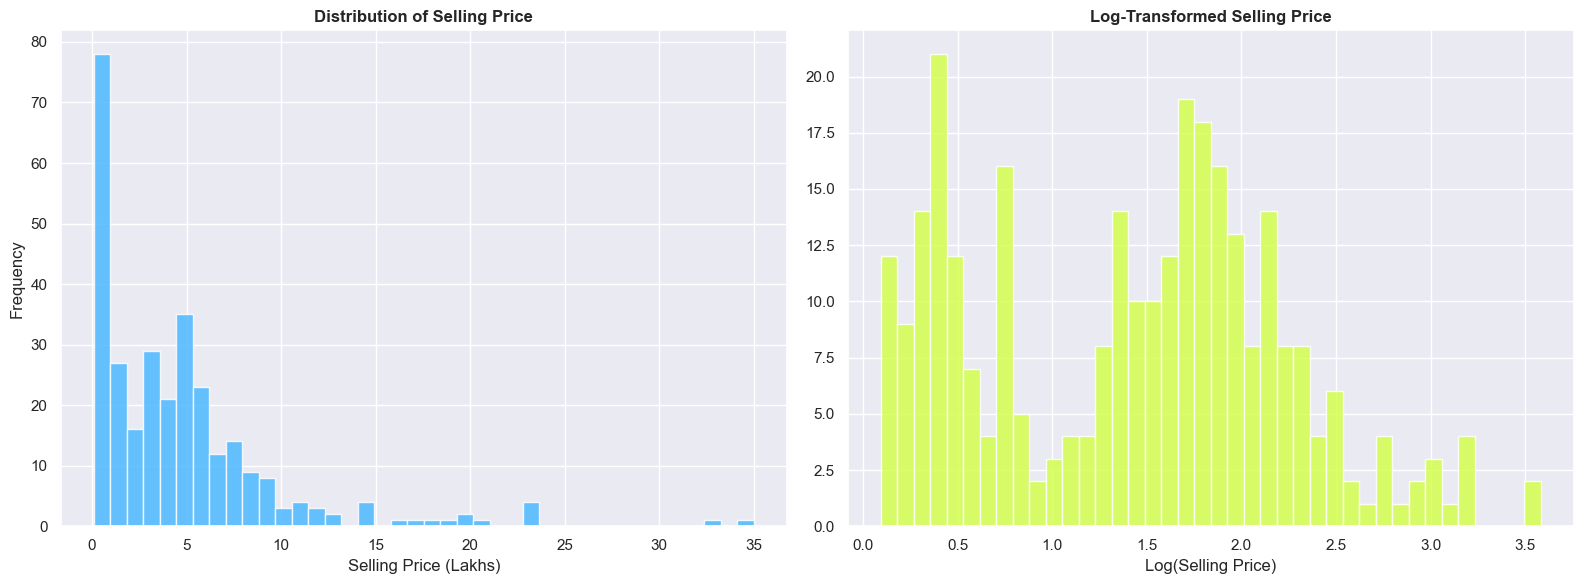

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(df['selling_price'], bins=40, color='#4db8ff', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Selling Price', fontweight='bold')
axes[0].set_xlabel('Selling Price (Lakhs)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['selling_price']), bins=40, color='#d4ff4e', edgecolor='white', alpha=0.85)
axes[1].set_title('Log-Transformed Selling Price', fontweight='bold')
axes[1].set_xlabel('Log(Selling Price)')

plt.tight_layout()
plt.savefig('plot_price_dist.png', dpi=150, bbox_inches='tight')
plt.show()

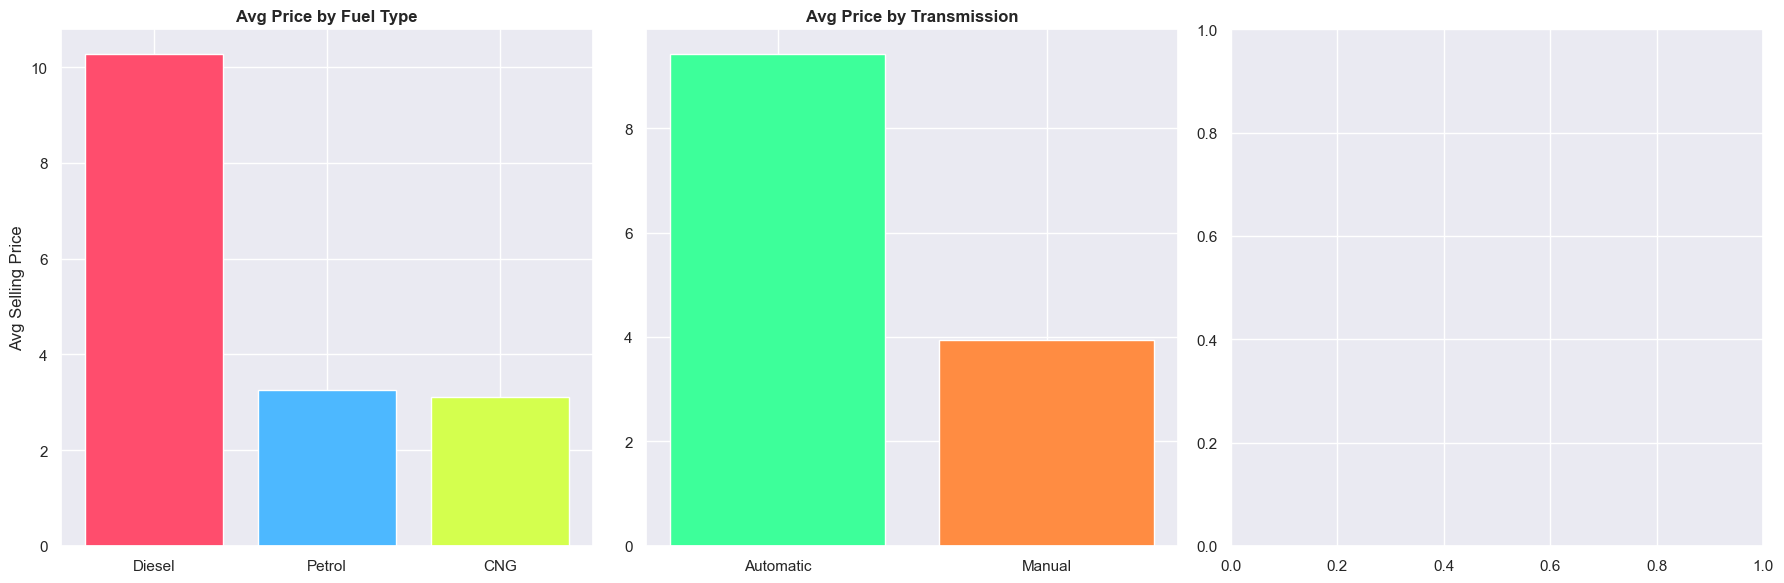

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

if 'fuel_type' in df.columns:
    fuel_avg = df.groupby('fuel_type')['selling_price'].mean().sort_values(ascending=False)
    axes[0].bar(fuel_avg.index, fuel_avg.values, color=['#ff4d6d','#4db8ff','#d4ff4e','#c084fc'], edgecolor='white')
    axes[0].set_title('Avg Price by Fuel Type', fontweight='bold')
    axes[0].set_ylabel('Avg Selling Price')

if 'transmission' in df.columns:
    trans_avg = df.groupby('transmission')['selling_price'].mean()
    axes[1].bar(trans_avg.index, trans_avg.values, color=['#3dff9a','#ff8c42'], edgecolor='white')
    axes[1].set_title('Avg Price by Transmission', fontweight='bold')

if 'seller_type' in df.columns:
    seller_avg = df.groupby('seller_type')['selling_price'].mean().sort_values(ascending=False)
    axes[2].bar(seller_avg.index, seller_avg.values, color=['#4db8ff','#ff4d6d','#d4ff4e'], edgecolor='white')
    axes[2].set_title('Avg Price by Seller Type', fontweight='bold')

plt.tight_layout()
plt.savefig('plot_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

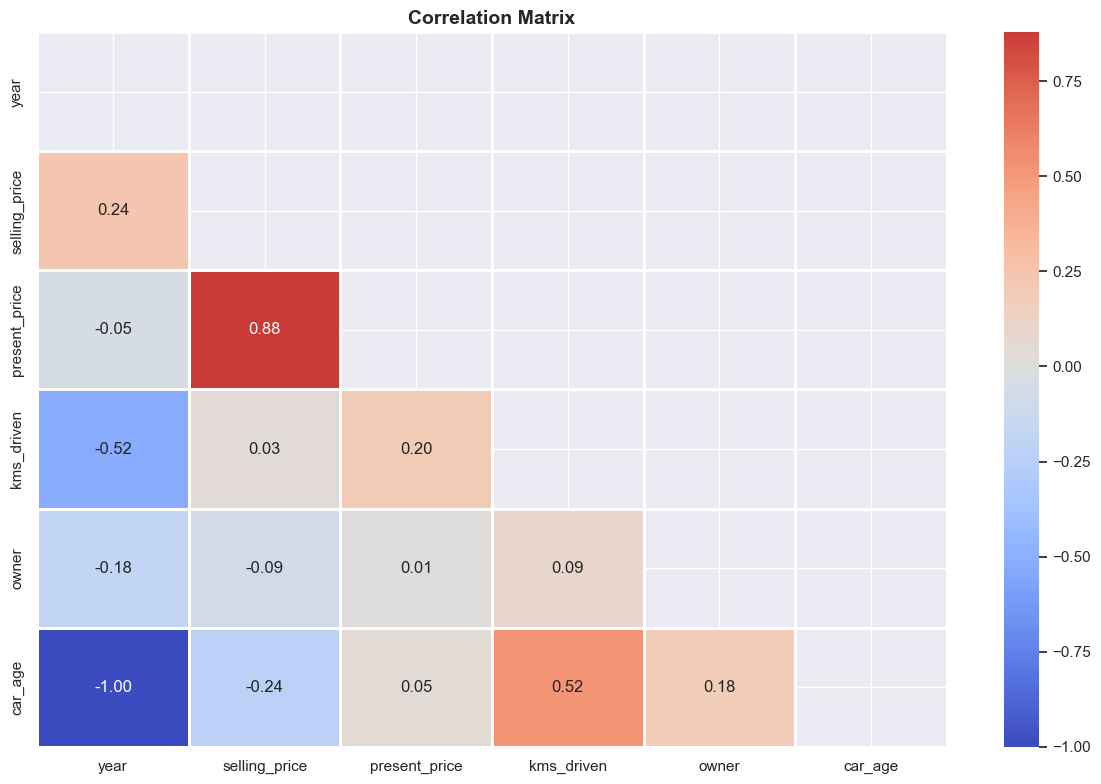

In [11]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, mask=mask, ax=ax, linewidths=1)
ax.set_title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_corr.png', dpi=150, bbox_inches='tight')
plt.show()

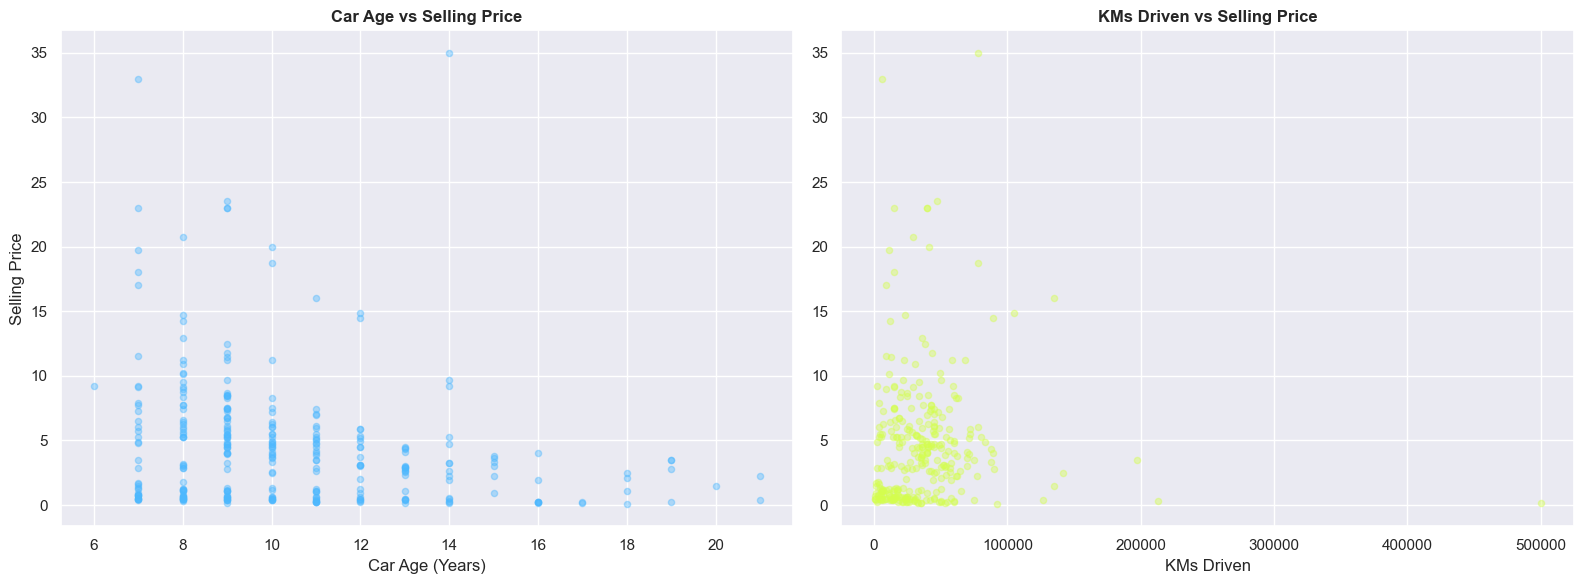

In [12]:
if 'car_age' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].scatter(df['car_age'], df['selling_price'], alpha=0.4, color='#4db8ff', s=20)
    axes[0].set_title('Car Age vs Selling Price', fontweight='bold')
    axes[0].set_xlabel('Car Age (Years)')
    axes[0].set_ylabel('Selling Price')

    axes[1].scatter(df['kms_driven'], df['selling_price'], alpha=0.4, color='#d4ff4e', s=20)
    axes[1].set_title('KMs Driven vs Selling Price', fontweight='bold')
    axes[1].set_xlabel('KMs Driven')
    plt.tight_layout()
    plt.savefig('plot_scatter.png', dpi=150, bbox_inches='tight')
    plt.show()

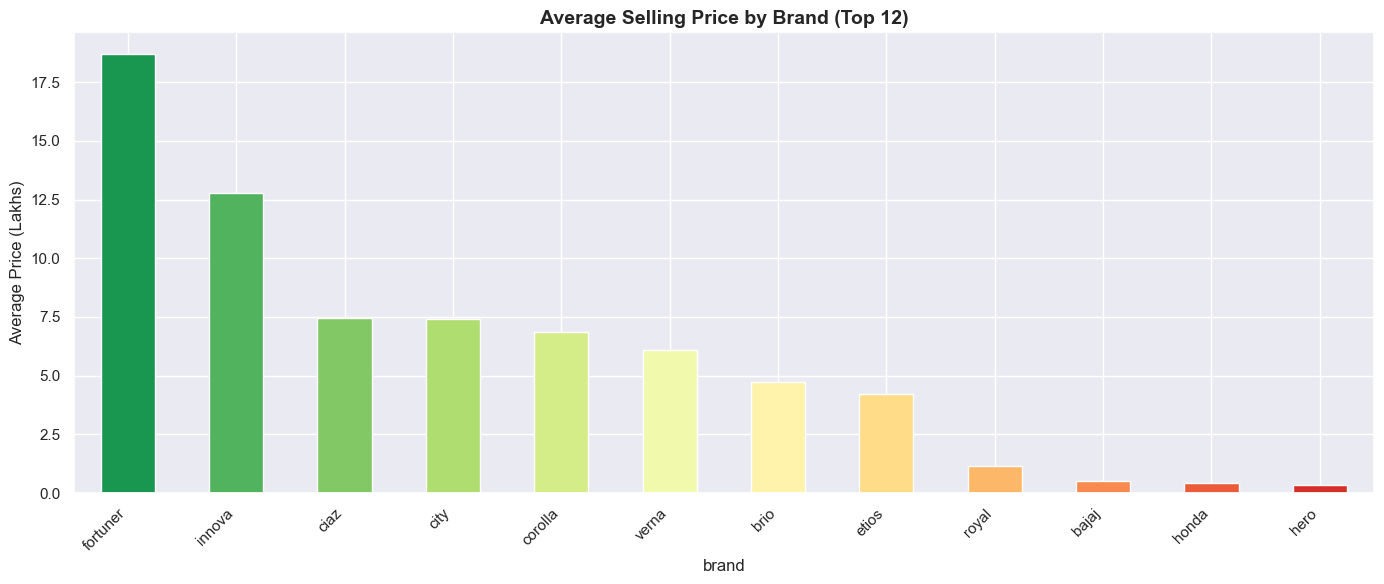

In [13]:
if 'brand' in df.columns:
    top_brands = df['brand'].value_counts().head(12).index
    brand_price = df[df['brand'].isin(top_brands)].groupby('brand')['selling_price'].mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = plt.cm.RdYlGn(np.linspace(0.9, 0.1, len(brand_price)))
    brand_price.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title('Average Selling Price by Brand (Top 12)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Average Price (Lakhs)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('plot_brand.png', dpi=150, bbox_inches='tight')
    plt.show()

In [14]:
le_fuel = LabelEncoder()
le_seller = LabelEncoder()
le_trans = LabelEncoder()

df_model = df.copy()

if 'fuel_type' in df_model.columns:
    df_model['fuel_encoded'] = le_fuel.fit_transform(df_model['fuel_type'])
if 'seller_type' in df_model.columns:
    df_model['seller_encoded'] = le_seller.fit_transform(df_model['seller_type'])
if 'transmission' in df_model.columns:
    df_model['trans_encoded'] = le_trans.fit_transform(df_model['transmission'])

feature_cols = [c for c in ['present_price','kms_driven','car_age','fuel_encoded','seller_encoded','trans_encoded','owner'] if c in df_model.columns]
target_col = 'selling_price'

X = df_model[feature_cols]
y = df_model[target_col]

print("Features:", feature_cols)
print("X shape:", X.shape)

Features: ['present_price', 'kms_driven', 'car_age', 'fuel_encoded', 'trans_encoded', 'owner']
X shape: (301, 6)


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f"R² Score : {r2:.4f}")
print(f"RMSE     : {rmse:.4f}")
print(f"MAE      : {mae:.4f}")

R² Score : 0.9589
RMSE     : 0.9728
MAE      : 0.6427


In [16]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=10),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=150, random_state=42)
}

results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    results.append({'Model': name, 'R²': round(r2_score(y_test,p),4), 'RMSE': round(np.sqrt(mean_squared_error(y_test,p)),4), 'MAE': round(mean_absolute_error(y_test,p),4)})

pd.DataFrame(results)

,Model,R²,RMSE,MAE
0,Linear Regression,0.8457,1.8852,1.2975
1,Ridge Regression,0.8458,1.8847,1.2842
2,Random Forest,0.9592,0.9698,0.6431
3,Gradient Boosting,0.9647,0.9016,0.5703


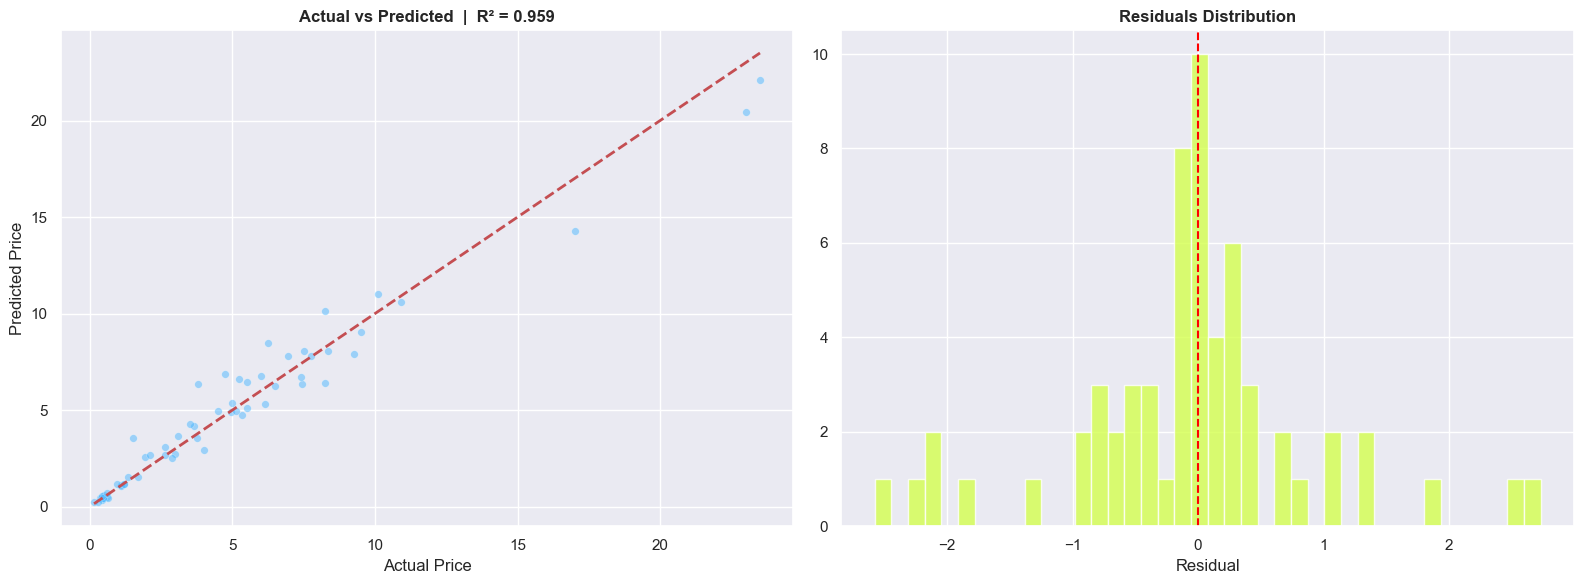

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test, y_pred, alpha=0.5, color='#4db8ff', s=30, edgecolors='white', lw=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Actual vs Predicted  |  R² = {r2:.3f}', fontweight='bold')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='#d4ff4e', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.savefig('plot_model_eval.png', dpi=150, bbox_inches='tight')
plt.show()

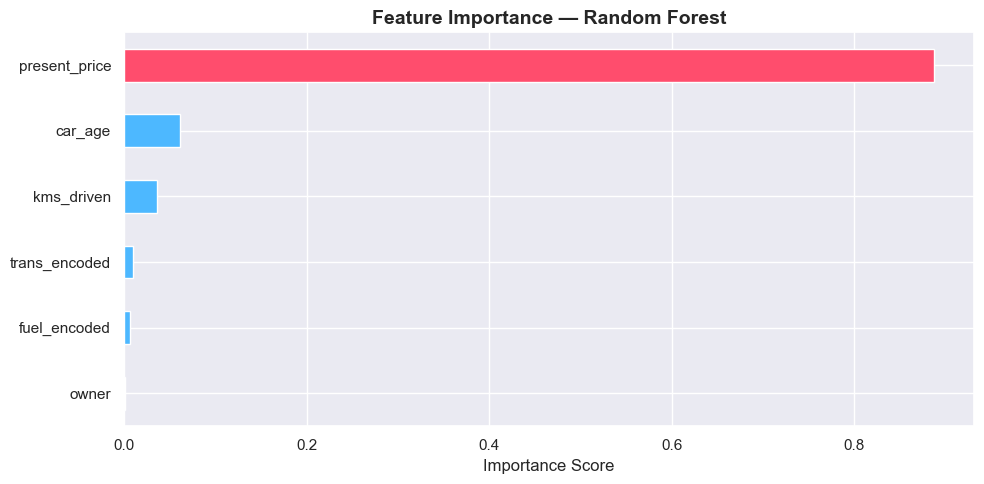

In [18]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ff4d6d' if v == importances.max() else '#4db8ff' for v in importances]
importances.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_feature_imp.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
joblib.dump(rf, 'car_price_model.pkl')
joblib.dump(le_fuel,   'le_fuel.pkl')
joblib.dump(le_seller, 'le_seller.pkl')
joblib.dump(le_trans,  'le_trans.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

fuel_classes   = le_fuel.classes_.tolist()   if hasattr(le_fuel,'classes_')   else []
seller_classes = le_seller.classes_.tolist() if hasattr(le_seller,'classes_') else []
trans_classes  = le_trans.classes_.tolist()  if hasattr(le_trans,'classes_')  else []

joblib.dump({'fuel': fuel_classes, 'seller': seller_classes, 'transmission': trans_classes}, 'label_classes.pkl')

print("car_price_model.pkl saved")
print("All encoders saved")
print(f"Final R² = {r2:.4f}")

car_price_model.pkl saved
All encoders saved
Final R² = 0.9589
